In [19]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import pandas as pd

In [20]:

# precio a vencimiento
def opcion_europea(CP, ST, K, r, T):
    if CP == 'call':
        
        payoff = np.maximum(ST - K, 0.0)
        
    else:
        payoff = np.maximum(K - ST, 0.0)
        
    return np.exp(-r*T) * np.mean(payoff)


def GeneratePathsGBM_givenZ(Z, T, r, sigma, S0):
    
    NoOfPaths, NoOfSteps = Z.shape

    X = np.zeros((NoOfPaths, NoOfSteps + 1))
    time = np.zeros(NoOfSteps + 1)

    dt = T / float(NoOfSteps)
    X[:, 0] = np.log(S0)

    for i in range(NoOfSteps):
        
        Zi = Z[:, i].copy()

        #normalizamos Z
        if NoOfPaths > 1:
            Zi = (Zi - np.mean(Zi)) / np.std(Zi)

        X[:, i+1] = X[:, i] + (r - 0.5*sigma**2) * dt + sigma * np.sqrt(dt) * Zi
        time[i+1] = time[i] + dt

    S = np.exp(X)
    
    return {"time": time, "S": S}

In [1]:
# VEGA, valor analítico
def BS_vega(S0, K, sigma, t, T, r):
    
    tau = T - t
    
    if tau <= 0:
        return 0.0
    
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    
    vega = S0 * norm.pdf(d1) * np.sqrt(tau)
    
    return vega

In [14]:
def PathwiseVega(CP, S0, S, K, r, T,sigma):
    ST = S[:, -1]
    
    if CP=='call':
        indicator = (ST > K).astype(float)

    elif CP=='put':
        indicator = (ST < K).astype(float)
    
    #derivada de ST respecto a Sigma
    WT = (np.log(ST / S0) - (r - 0.5 * sigma**2) * T)/sigma
    
    vega = np.exp(-r * T) * np.mean(indicator * ST * (WT-sigma*T))
 
    return vega


In [10]:
def FDCentradaVega(CP, S0, K, r, T, sigma, NoOfPaths, NoOfSteps, h, Z):
    if Z is None:
        Z = np.random.normal(0.0, 1.0, (NoOfPaths, NoOfSteps))

    paths_up = GeneratePathsGBM_givenZ(Z, T, r, sigma + h, S0)
    paths_dn = GeneratePathsGBM_givenZ(Z, T, r, sigma - h, S0)

    ST_up = paths_up["S"][:, -1]
    ST_dn = paths_dn["S"][:, -1]

    price_up = opcion_europea(CP, ST_up, K, r, T)
    price_dn = opcion_europea(CP, ST_dn, K, r, T)

    return (price_up - price_dn) / (2 * h)

In [4]:
#Ejemplo
CP = 'call'
S0 = 100
K = 100
r = 0.05
sigma = 0.2
T = 1.0
NoOfPaths = 100000
NoOfSteps = 1
h = 0.01
t=0

In [15]:
rng = np.random.default_rng()

Z = rng.normal(0.0, 1.0, (NoOfPaths, NoOfSteps))

paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
vega_pw = PathwiseVega(CP, S0, paths["S"], K, r, T,sigma)

vega_fd=FDCentradaVega(CP, S0, K, r, T, sigma, NoOfPaths, NoOfSteps, h, Z)

vega_bs=BS_vega(S0,K,sigma,t,T,r)


print("Vega Black-Scholes:", vega_bs)
print("Vega Pathwise:", vega_pw)
print("Vega Finite Differences:", vega_fd)
print(' ')

print("Error abs PW:", abs(vega_pw - vega_bs))
print("Error abs FD:", abs(vega_fd - vega_bs))

Vega Black-Scholes: 37.52403469169379
Vega Pathwise: 37.63456368361764
Vega Finite Differences: 37.628945892787335
 
Error abs PW: 0.11052899192385013
Error abs FD: 0.10491120109354313


##### 1. Dependencia de N

In [17]:
def estimadores_vega(CP, S0, K, r, T, sigma, NoOfPaths, NoOfSteps, h):
    Z = np.random.normal(0.0, 1.0, (NoOfPaths, NoOfSteps))
    
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    S = paths["S"]
    
    vega_pw = PathwiseVega(CP, S0, S, K, r, T, sigma)
    vega_fd = FDCentradaVega(CP, S0, K, r, T, sigma, NoOfPaths, NoOfSteps, h, Z=Z)
    
    return vega_pw, vega_fd

,N_paths,Vega_Pathwise,Error_Pathwise,Vega_FD,Error_FD,MC_rate
0,1000,38.510045,0.986011,38.472338,0.948303,0.031623
1,5000,37.550580,0.026545,37.552216,0.028181,0.014142
2,10000,37.610009,0.085975,37.599768,0.075733,0.010000
3,50000,37.606673,0.082639,37.596799,0.072764,0.004472
4,100000,37.515574,0.008461,37.508006,0.016029,0.003162


<Axes: xlabel='N_paths'>

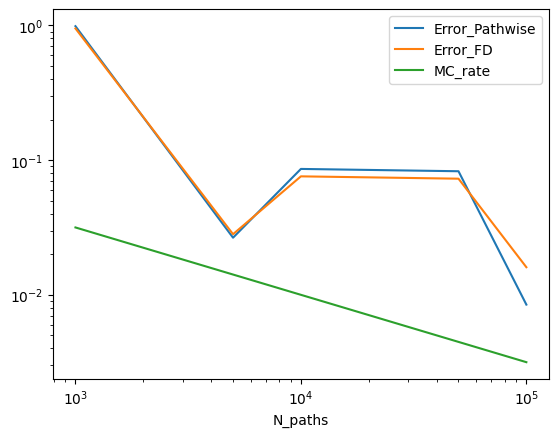

In [21]:
N_list = [1000, 5000, 10000, 50000, 100000]
results = []

vega_bs = BS_vega(S0, K, sigma, t, T, r)

for N in N_list:
    vega_pw, vega_fd = estimadores_vega(
        CP='call',
        S0=S0,
        K=K,
        r=r,
        T=T,
        sigma=sigma,
        NoOfPaths=N,
        NoOfSteps=NoOfSteps,
        h=0.01
    )
    
    results.append([
        N,
        vega_pw,
        abs(vega_pw - vega_bs),
        vega_fd,
        abs(vega_fd - vega_bs),
        1 / np.sqrt(N)
    ])

results = pd.DataFrame(results, columns=[
    "N_paths",
    "Vega_Pathwise",
    "Error_Pathwise",
    "Vega_FD",
    "Error_FD",
    "MC_rate"
])

display(results)

results.plot(
    x="N_paths",
    y=["Error_Pathwise", "Error_FD", "MC_rate"],
    logx=True,
    logy=True
)

Ambos estimadores presentan una precisión similar, aunque el estimador de Vega muestra mayor variabilidad que el de Delta debido a la presencia del término aleatorio WT en pathwise.

##### 2. Dependencia en h

,h,Mean_Pathwise,Bias_Pathwise,Var_Pathwise,MSE_Pathwise,Mean_FD_centered,Bias_FD_centered,Var_FD_centered,MSE_FD_centered
0,0.100,37.525203,0.001168,0.028611,0.028613,37.133749,-0.390285,0.026180,0.178503
1,0.050,37.525203,0.001168,0.028611,0.028613,37.444299,-0.079736,0.027680,0.034038
2,0.010,37.525203,0.001168,0.028611,0.028613,37.521693,-0.002342,0.028425,0.028431
3,0.005,37.525203,0.001168,0.028611,0.028613,37.524476,0.000441,0.028472,0.028472
4,0.001,37.525203,0.001168,0.028611,0.028613,37.525199,0.001164,0.028584,0.028585


,h,Error_Pathwise,Error_FD
0,0.001,0.135583,0.135411
1,0.005,0.135583,0.135161
2,0.010,0.135583,0.135058
3,0.050,0.135583,0.146709
4,0.100,0.135583,0.392113


<Axes: xlabel='h'>

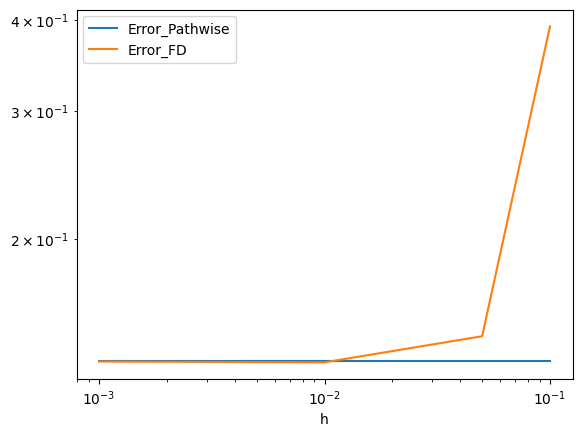

In [30]:
h_list = [0.1, 0.05, 0.01, 0.005, 0.001]
N = 10000
M = 500

vega_bs = BS_vega(S0, K, sigma, t, T, r)

results_h = []
errors_h=[]

pw_all = []
fd_all_dict = {h: [] for h in h_list}

for _ in range(M):
    Z = np.random.normal(0.0, 1.0, (N, NoOfSteps))

    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    S = paths["S"]
    vega_pw = PathwiseVega(CP, S0, S, K, r, T, sigma)
    pw_all.append(vega_pw)

    for h in h_list:
        vega_fd = FDCentradaVega(
            CP, S0, K, r, T, sigma, N, NoOfSteps, h, Z=Z
        )

        errors_h.append([h,abs(vega_pw - vega_bs),abs(vega_fd - vega_bs)])
        
        fd_all_dict[h].append(vega_fd)

pw_all = np.array(pw_all)

mean_pw = np.mean(pw_all)
var_pw = np.var(pw_all, ddof=1)
bias_pw = mean_pw - vega_bs
mse_pw = var_pw + bias_pw**2

for h in h_list:
    fd_values = np.array(fd_all_dict[h])

    mean_fd = np.mean(fd_values)
    var_fd = np.var(fd_values, ddof=1)
    bias_fd = mean_fd - vega_bs
    mse_fd = var_fd + bias_fd**2

    results_h.append([
        h,
        mean_pw, bias_pw, var_pw, mse_pw,
        mean_fd, bias_fd, var_fd, mse_fd
    ])

    

results_h = pd.DataFrame(results_h, columns=[
    "h",
    "Mean_Pathwise", "Bias_Pathwise", "Var_Pathwise", "MSE_Pathwise",
    "Mean_FD_centered", "Bias_FD_centered", "Var_FD_centered", "MSE_FD_centered"
])

display(results_h)

errors_h = pd.DataFrame(errors_h, columns=[
    "h",
    "Error_Pathwise",
    "Error_FD"
])

errors_h_mean = errors_h.groupby("h", as_index=False).mean()

display(errors_h_mean)

errors_h_mean.plot(
    x="h",
    y=["Error_Pathwise", "Error_FD"],
    logx=True,
    logy=True
)


Pathwise no depende de h
Parece que el mejor h está aproximadamente en: 0.01

El estimador de diferencias finitas tiene dependencia respecto a h. Para valores grandes de h, el error está dominado por el sesgo de la aproximación numérica, pero para valores muy pequeños aumenta la influencia del ruido Monte Carlo. Porque cuando h es pequeño en montecarlo restamos valores muuuuy parecidos.

